In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean default look for the charts
sns.set_theme(style="whitegrid")

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')
titanic = titanic.dropna(subset=['age', 'fare', 'embarked'])
#removes incomplete rows with missing values in 'age', 'fare', and 'embarked' columns
#cannot calculate on null values as if we plot age vs fare  it will throw an error.
#sibsp and parch are sibling spouse and parents childrens.

# Display first 6 rows
titanic.head(6)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True


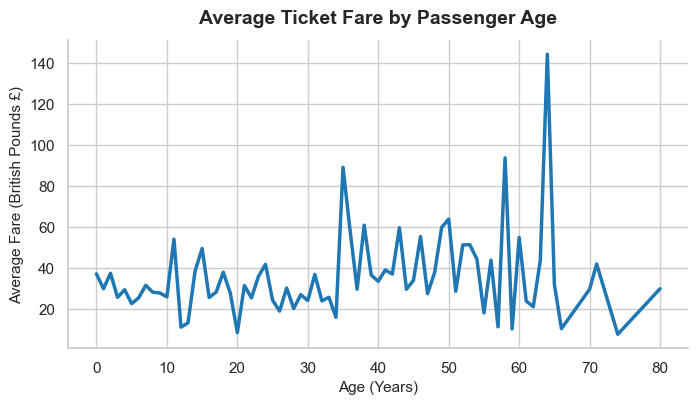

In [20]:
# 1. Prepare data (Group ages into whole numbers and calculate average fare)
age_fare = titanic.groupby(titanic['age'].astype(int))['fare'].mean()

# 2. Plotting (Matplotlib Chart 1)
plt.figure(figsize=(8, 4))
plt.plot(age_fare.index, age_fare.values, color='#1f77b4', linewidth=2.5)  # Sleek Royal Blue

# 3. Labeling (Required Axes and Titles)
plt.title('Average Ticket Fare by Passenger Age', fontsize=14, pad=12, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=11)
plt.ylabel('Average Fare (British Pounds £)', fontsize=11)

# 4. Modern Tweak: Despining (Removes top and right box borders)
sns.despine()

plt.show()



**Insight:** This line chart shows that ticket prices remained relatively stable across ages youth and mid, but spiked significantly for elderly passengers near passangers between 60 to 70 years old.

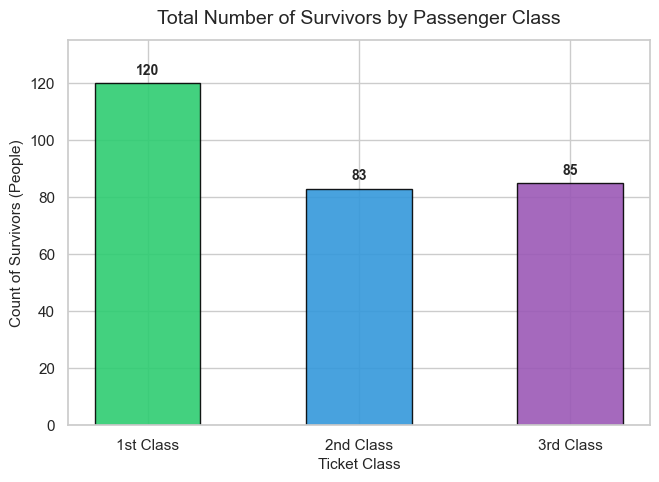

In [18]:
# 1. Prepare data (Calculate survival counts per ticket class)
class_survival = titanic.groupby('pclass')['survived'].sum()

# 2. Plotting (Matplotlib Chart 2)
plt.figure(figsize=(7.5, 5))
classes = ['1st Class', '2nd Class', '3rd Class']
counts = class_survival.values

# Assign unique colors to each class bar
bar_colors = ['#2ecc71', '#3498db', '#9b59b6']  # Green, Blue, Purple
bars = plt.bar(classes, counts, color=bar_colors, width=0.5, edgecolor='black', alpha=0.9)

# 3. Add values to the top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 2,                      # Position the text slightly above the top edge
        f'{int(yval)}',                 # The exact count number
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

# 4. Labeling
plt.title('Total Number of Survivors by Passenger Class', fontsize=14, pad=12)
plt.xlabel('Ticket Class', fontsize=11)
plt.ylabel('Count of Survivors (People)', fontsize=11)

# Increase y-axis limit slightly so the text doesn't hit the border
plt.ylim(0, max(counts) + 15)

plt.show()



**Insight:** The bar chart shows that 1st Class had the highest absolute number of survivors, while 2nd and 3rd Class had significantly lower survival counts despite having a larger total passenger count on the ship.

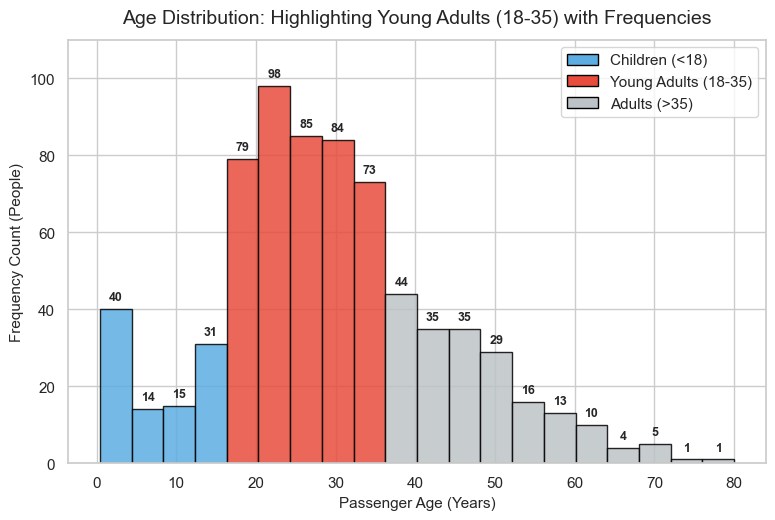

In [ ]:
import numpy as np
from matplotlib.patches import Patch

# 1. Create the base histogram layout
plt.figure(figsize=(9, 5.5))
counts, bins, patches = plt.hist(titanic['age'], bins=20, edgecolor='black', alpha=0.85)

# 2. Get current axes to add text labels, tweek specific design that matplotlib doesn't handle by default.
ax = plt.gca()

# 3. Loop through each bar to color it AND add the count label on top
for i in range(len(patches)):
    bin_center = (bins[i] + bins[i+1]) / 2
    height = counts[i]
    
    # Apply special colors to specific age brackets
    if bin_center < 18:
        patches[i].set_facecolor('#5dade2')  # Soft Blue for Children
    elif 18 <= bin_center <= 35:
        patches[i].set_facecolor('#e74c3c')  # Bright Red for Young Adults
    else:
        patches[i].set_facecolor('#bdc3c7')  # Muted Gray for Older Adults
        
    # Only show numbers for bars that actually have data (height > 0)
    if height > 0:
        ax.text(
            bin_center, 
            height + 1.5,          # Position the text slightly above the bar top
            f'{int(height)}',      # The actual count number
            ha='center', 
            va='bottom', 
            fontsize=9, 
            fontweight='bold'
        )

# 4. Required Axes Labeling, Title, and Legend
plt.title('Age Distribution: Highlighting Young Adults (18-35) with Frequencies', fontsize=14, pad=12)
plt.xlabel('Passenger Age (Years)', fontsize=11)
plt.ylabel('Frequency Count (People)', fontsize=11)

# Set the y-axis limit a bit higher so the top numbers don't get cut off
plt.ylim(0, max(counts) + 12) #adding some space on top of the bar for the text labels.

legend_elements = [Patch(facecolor='#5dade2', edgecolor='black', label='Children (<18)'),
                   Patch(facecolor='#e74c3c', edgecolor='black', label='Young Adults (18-35)'),
                   Patch(facecolor='#bdc3c7', edgecolor='black', label='Adults (>35)')]
plt.legend(handles=legend_elements, loc='upper right')

plt.show()



**Insight:** The color-coded histogram clearly highlights that the passenger demographics skewed heavily toward young adults (16–35 years old), who form the largest cluster aboard the vessel, peaking at 98 individuals in the 20-24 age bracket.

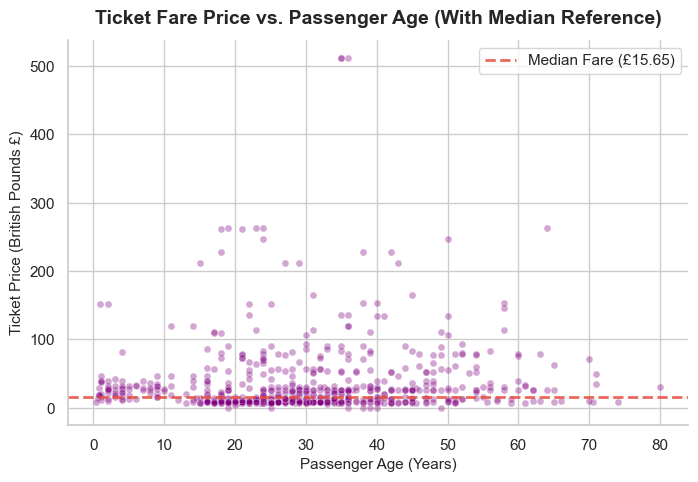

In [31]:
# 1. Plotting with anti-overlap adjustments
plt.figure(figsize=(8, 5))

# Plot the individual passenger dots
plt.scatter(
    titanic['age'], 
    titanic['fare'], 
    color='purple', 
    alpha=0.35, 
    edgecolors='white', 
    linewidth=0.5, 
    s=25
)

# 2. Add the Target Line (Overall Median Fare)
median_fare = titanic['fare'].median()
plt.axhline(
    median_fare, 
    color='#e74c3c',       # Crisp Red
    linestyle='--',        # Dashed line style
    linewidth=2, 
    alpha=0.85,
    label=f'Median Fare (£{median_fare:.2f})'
)

# 3. Labeling
plt.title('Ticket Fare Price vs. Passenger Age (With Median Reference)', fontsize=14, pad=12, fontweight='bold')
plt.xlabel('Passenger Age (Years)', fontsize=11)
plt.ylabel('Ticket Price (British Pounds £)', fontsize=11)

# Position the legend to show what the red line represents
plt.legend(loc='upper right')

# Modern Tweak: Despining (Removes top and right box borders)
sns.despine()

plt.show()



**Insight:** The scatter plot reveals that the vast majority of passengers clustered below the overall median fare line of £15.65 across all age groups, visually highlighting how elite the few high-paying luxury outliers truly were .few elites payed much higher fare taking of high luxury facilities like around and above 500 pounds.

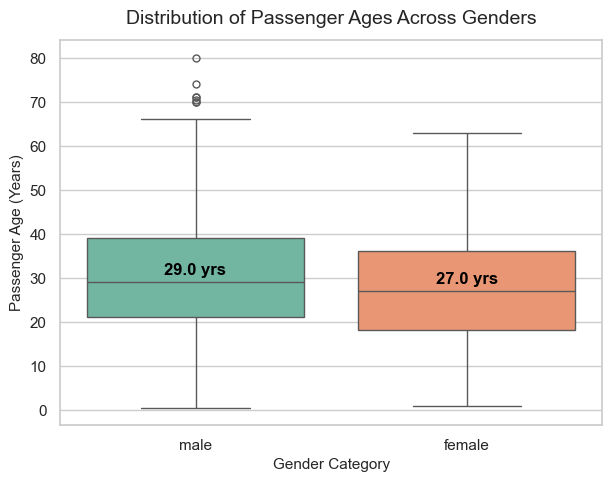

In [15]:
# 1. Calculate exact medians programmatically
male_median = titanic[titanic['sex'] == 'male']['age'].median()
female_median = titanic[titanic['sex'] == 'female']['age'].median()

# 2. Plotting using Seaborn
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x='sex', y='age', data=titanic, palette='Set2', hue='sex', legend=False, fliersize=5)

# 3. Dynamic Text Overlay on top of the median lines
ax.text(0, male_median + 1, f'{male_median:.1f} yrs', ha='center', va='bottom', color='black', fontweight='bold')
ax.text(1, female_median + 1, f'{female_median:.1f} yrs', ha='center', va='bottom', color='black', fontweight='bold')

# 4. Labeling
plt.title('Distribution of Passenger Ages Across Genders', fontsize=14, pad=12)
plt.xlabel('Gender Category', fontsize=11)
plt.ylabel('Passenger Age (Years)', fontsize=11)

plt.show()



**Insight:** The box plot demonstrates that male passengers had a slightly higher  median age than female passengers, with male  displaying elderly outliers from age 68 to 80 years old .

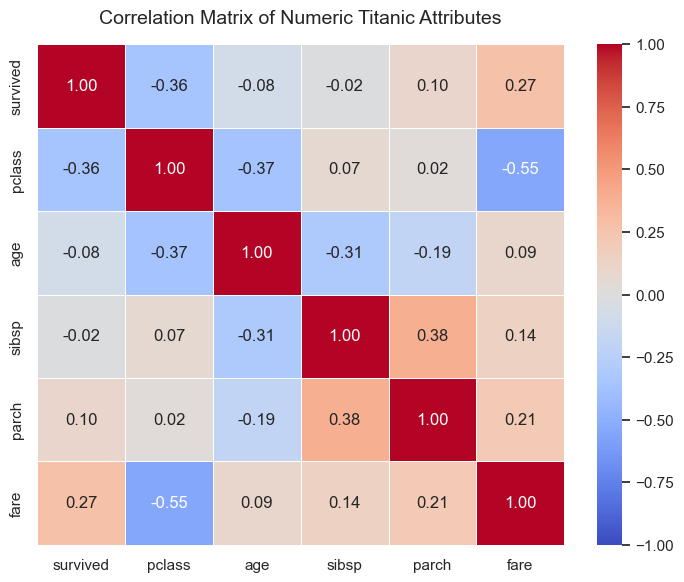

In [19]:
# 1. Filter out only the numeric columns for correlation calculation
numeric_columns = titanic[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']]
correlation_matrix = numeric_columns.corr()

# 2. Plotting (Seaborn Chart 6)
plt.figure(figsize=(8.5, 6.5))

# sns.heatmap automatically prints the grid with clean color coding
sns.heatmap(
    correlation_matrix, 
    annot=True,             # Displays the actual correlation numbers inside each box
    cmap='coolwarm',        # Red means positive correlation, blue means negative
    fmt=".2f",              # Rounds numbers to 2 decimal places
    linewidths=0.5,         # Adds white grid lines between the boxes
    vmin=-1, vmax=1         # Sets the standard color scale limits from -1 to 1
)

# 3. Labeling (Required Title)
plt.title('Correlation Matrix of Numeric Titanic Attributes', fontsize=14, pad=15)

plt.show()


**Insight:** The correlation matrix reveals a 
strong negative relationship (-0.55) between ticket class (pclass) and fare price 
meaning as class num drpos the fare increses .
Family Structure Co-Linearity (sibsp vs. parch +0.38 slight positive co-rrelation .)

The Wealth surviaval Factor (fare vs. survived +0.27 slight positive co-rrelation , which decipts the factor of having survived as upper deck cabin placements.)

The Classgap and age (pclass vs. age -0.37 negative co-rrelation . richer or older  were in expensive cabins while low count but poor or young were in cheaper class cabins while higher count )

The family travel units (sibsp vs parch  0.38  weak co-rrelation . showed passengers travelled in famil clusters)

The age sibking/spouse relation (age vs sibsp -0.31   weak negative co-rrelation .)


The correlation matrix reveals that survival on the Titanic was not random; instead, it was heavily driven by socio-economic status and family dynamics.



reading any correlation matrix:(+1.00) (Deep Red): Perfect positive correlation (a column compared to itself)
.Near (0.00) (Light/White): No linear relationship or pattern whatsoever.
(-0.50) to (-1.00) (Deep Blue): Strong inverse relationship (as one number goes up, the other drops).

TASK 2 STARTS FROM HERE 

### 📊 TASK 2 Dashboard Analysis: Wealth and Vulnerability Aboard the Titanic
This dashboard explores how socio-economic privilege and demographic characteristics directly influenced a passenger's likelihood of survival during the 1912 disaster. By examining the interplay between ticket class, ticket fares, age, gender, and survival status, a clear narrative emerges showing that wealth bought a literal path to safety. Ultimately, the data illustrates that institutional structural inequalities heavily favored wealthy first-class passengers and female travelers during evacuation protocols.


C:\Users\User\AppData\Local\Temp\ipykernel_10016\72213721.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
C:\Users\User\AppData\Local\Temp\ipykernel_10016\72213721.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
C:\Users\User\AppData\Local\Temp\ipykernel_10016\72213721.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Male', 'Female'])
C:\Users\User\AppData\Local\Temp\ipykernel_10016\72213721.py:95: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_10016\72213721.py:98: UserWarning

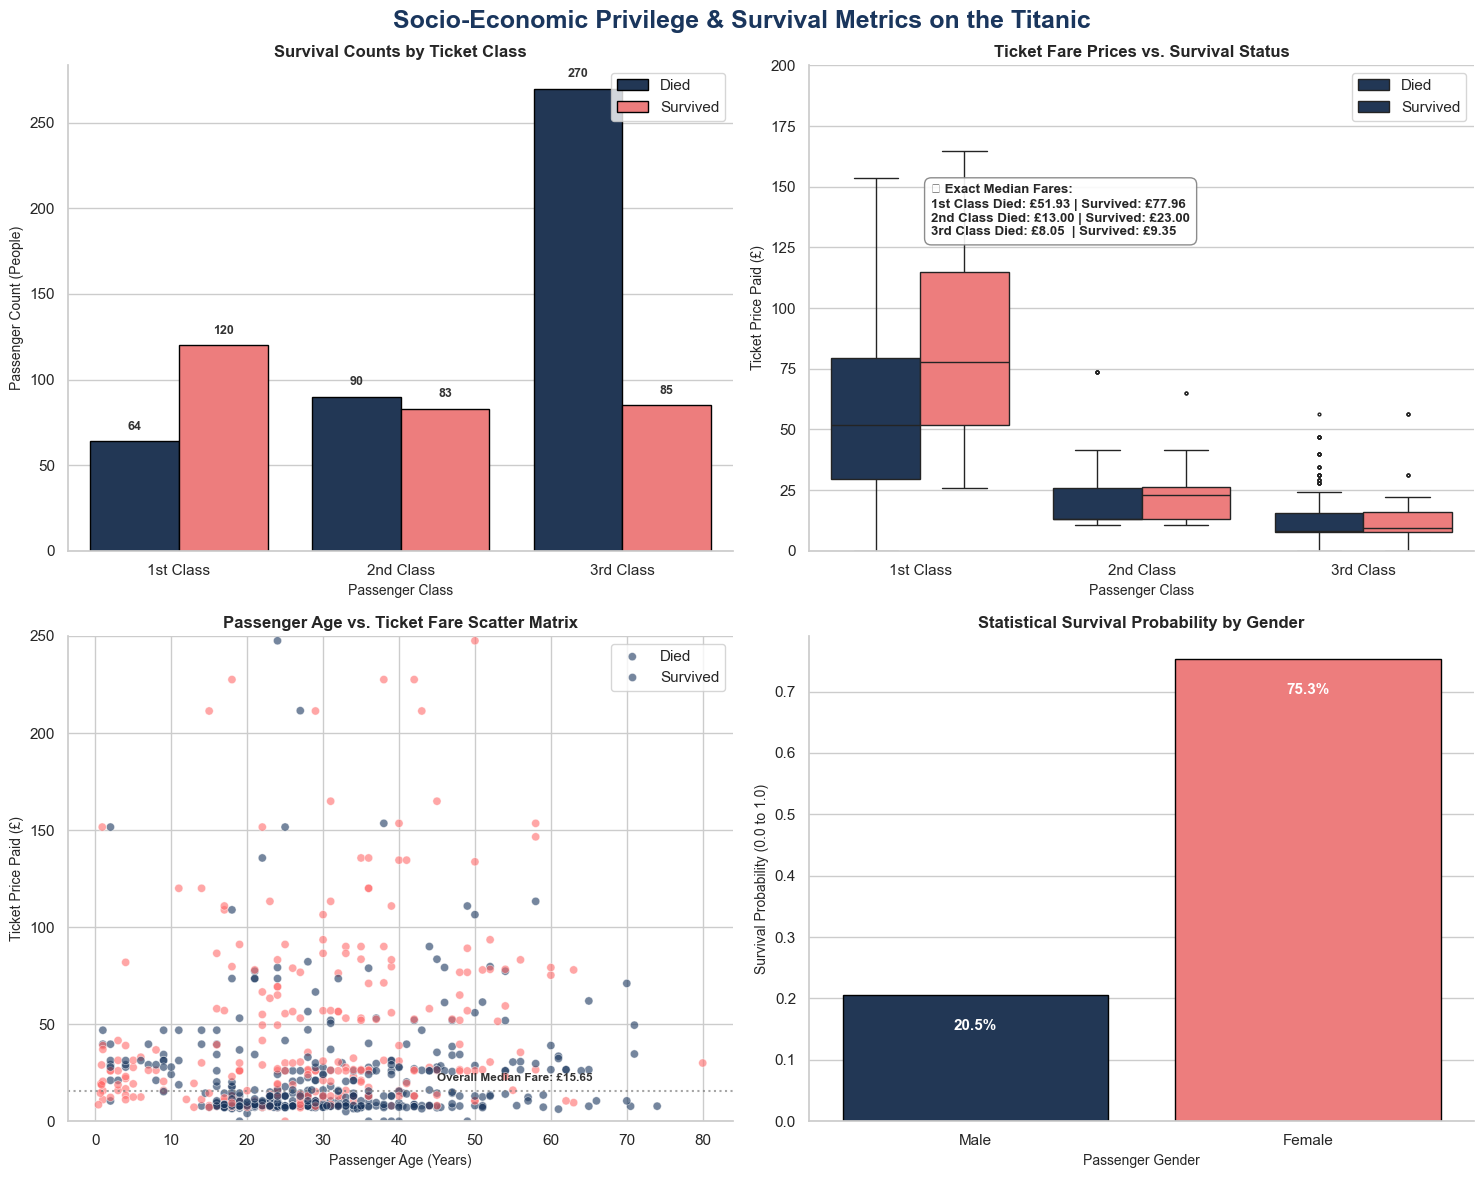

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure theme and colors are locked in
sns.set_theme(style="whitegrid")
unified_colors = ['#1a365d', '#ff6b6b']  # Navy Blue (Died) and Coral Red (Survived)

# 1. Initialize a 2x2 Subplot Grid framework
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
fig.suptitle('Socio-Economic Privilege & Survival Metrics on the Titanic', fontsize=18, fontweight='bold', color='#1a365d', y=0.98)

# ==========================================
# PLOT 1 (Top Left): Categorical Survival by Class with Bar Values
# ==========================================
sns.countplot(x='pclass', hue='survived', data=titanic, palette=unified_colors, ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('Survival Counts by Ticket Class', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Passenger Class', fontsize=10)
axes[0, 0].set_ylabel('Passenger Count (People)', fontsize=10)
axes[0, 0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
axes[0, 0].legend(['Died', 'Survived'], loc='upper right')

# Add precise count numbers on top of each bar
for p in axes[0, 0].patches:
    if p.get_height() > 0:
        axes[0, 0].annotate(f'{int(p.get_height())}', 
                            (p.get_x() + p.get_width() / 2., p.get_height() + 5),
                            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')

# ==========================================
# PLOT 2 (Top Right): Numeric Fare Distribution with Summary Legend
# ==========================================
sns.boxplot(x='pclass', y='fare', hue='survived', data=titanic, palette=unified_colors, ax=axes[0, 1], fliersize=2)
axes[0, 1].set_title('Ticket Fare Prices vs. Survival Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Passenger Class', fontsize=10)
axes[0, 1].set_ylabel('Ticket Price Paid (£)', fontsize=10)
axes[0, 1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
axes[0, 1].set_ylim(0, 200) 
axes[0, 1].legend(['Died', 'Survived'], loc='upper right')

# Calculate exact medians programmatically
m1_d = titanic[(titanic['pclass'] == 1) & (titanic['survived'] == 0)]['fare'].median()
m1_s = titanic[(titanic['pclass'] == 1) & (titanic['survived'] == 1)]['fare'].median()
m2_d = titanic[(titanic['pclass'] == 2) & (titanic['survived'] == 0)]['fare'].median()
m2_s = titanic[(titanic['pclass'] == 2) & (titanic['survived'] == 1)]['fare'].median()
m3_d = titanic[(titanic['pclass'] == 3) & (titanic['survived'] == 0)]['fare'].median()
m3_s = titanic[(titanic['pclass'] == 3) & (titanic['survived'] == 1)]['fare'].median()

# Create a beautifully formatted text box overlaying the median values inside the plot
median_summary_text = (
    f"📊 Exact Median Fares:\n"
    f"1st Class Died: £{m1_d:.2f} | Survived: £{m1_s:.2f}\n"
    f"2nd Class Died: £{m2_d:.2f} | Survived: £{m2_s:.2f}\n"
    f"3rd Class Died: £{m3_d:.2f}  | Survived: £{m3_s:.2f}"
)
axes[0, 1].text(0.05, 130, median_summary_text, fontsize=9.5, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

# ==========================================
# PLOT 3 (Bottom Left): Passenger Age vs. Ticket Fare Scatter Matrix
# ==========================================
sns.scatterplot(x='age', y='fare', hue='survived', data=titanic, palette=unified_colors, ax=axes[1, 0], alpha=0.6, edgecolor='white', s=35)
axes[1, 0].set_title('Passenger Age vs. Ticket Fare Scatter Matrix', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Passenger Age (Years)', fontsize=10)
axes[1, 0].set_ylabel('Ticket Price Paid (£)', fontsize=10)
axes[1, 0].set_ylim(0, 250)
axes[1, 0].legend(['Died', 'Survived'], loc='upper right')

# Add baseline median fare indicator line
overall_median = titanic['fare'].median()
axes[1, 0].axhline(overall_median, color='gray', linestyle=':', alpha=0.7)
axes[1, 0].text(45, overall_median + 5, f'Overall Median Fare: £{overall_median:.2f}', fontsize=8.5, color='#333333', weight='bold')

# ==========================================
# PLOT 4 (Bottom Right): Statistical Survival Probability by Gender
# ==========================================
sns.barplot(x='sex', y='survived', data=titanic, palette=unified_colors, ax=axes[1, 1], errorbar=None, edgecolor='black', hue='sex', legend=False)
axes[1, 1].set_title('Statistical Survival Probability by Gender', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Passenger Gender', fontsize=10)
axes[1, 1].set_ylabel('Survival Probability (0.0 to 1.0)', fontsize=10)
axes[1, 1].set_xticklabels(['Male', 'Female'])

# Add percentage labels directly inside the bars
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f'{p.get_height()*100:.1f}%', 
                        (p.get_x() + p.get_width() / 2., p.get_height() - 0.05),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# ==========================================
# FINAL CLEANUP, DESPINNING, AND HIGH-RES EXPORT
# ==========================================
for row in axes:
    for ax in row:
        sns.despine(ax=ax)

plt.tight_layout()

# Save the plot frames at high resolution (300 DPI) as required
plt.savefig('titanic_storytelling_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()



TASK 3 STARTS HERE 

## 🌐 Task 3: Interactive Plotly Dashboard & Web Report
Interactive hoverable info showing chart


In [27]:

import plotly.express as px
import plotly.io as pio

# Map numeric 0 and 1 to clean text strings for better legends
titanic_plotly = titanic.copy()
titanic_plotly['survived_text'] = titanic_plotly['survived'].map({0: 'Died', 1: 'Survived'})

# ==========================================
# 1. Interactive Bar Chart (Recreated Chart 2)
# ==========================================
fig1 = px.histogram(
    titanic_plotly, 
    x="pclass", 
    color="survived_text",
    barmode="group",
    title="Interactive View: Survival Counts Across Ticket Classes",
    labels={"pclass": "Ticket Class", "count": "Passenger Count", "survived_text": "Status"},
    color_discrete_map={'Died': '#1a365d', 'Survived': '#ff6b6b'},
    hover_data=["sex", "embarked"]  # Custom tooltips
)
fig1.update_xaxes(type='category', tickvals=[1, 2, 3], ticktext=['1st Class', '2nd Class', '3rd Class'])
fig1.show()
pio.write_html(fig1, file='interactive_bar_chart.html', auto_open=False)


# ==========================================
# 2. Interactive Histogram (Recreated Chart 3)
# ==========================================
fig2 = px.histogram(
    titanic_plotly, 
    x="age", 
    nbins=20,
    title="Interactive View: Demographics & Age Frequencies",
    labels={"age": "Passenger Age (Years)", "count": "Frequency Count"},
    color_discrete_sequence=['#e74c3c'],
    hover_data=["sex", "pclass"]  
)
fig2.show()
pio.write_html(fig2, file='interactive_histogram.html', auto_open=False)


# ==========================================
# 3. Interactive Scatter Plot (Recreated Chart 4)
# ==========================================
fig3 = px.scatter(
    titanic_plotly, 
    x="age", 
    y="fare", 
    color="survived_text",
    title="Interactive View: Ticket Fare Price vs. Passenger Age Matrix",
    labels={"age": "Passenger Age (Years)", "fare": "Ticket Fare Paid (£)", "survived_text": "Status"},
    color_discrete_map={'Died': '#1a365d', 'Survived': '#ff6b6b'},
    opacity=0.7,
    hover_data=["sex", "pclass", "embark_town"]  
)
fig3.show()
pio.write_html(fig3, file='interactive_scatter_plot.html', auto_open=False)


# ==========================================
# 4. Advanced 4th Chart Type: Sunburst Chart
# ==========================================
fig4 = px.sunburst(
    titanic_plotly, 
    path=['pclass', 'sex'], 
    values='fare',
    title="Advanced Sunburst Analysis: Fare Distribution Grouped by Class and Gender Hierarchy",
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig4.show()
pio.write_html(fig4, file='interactive_sunburst_chart.html', auto_open=False)



### 🧠 Advanced Plotly Rationale and Feature Evaluation
Transitioning from static visual layouts to browser-native interactive plots using Plotly Express drastically increases usability. By configuring custom tooltips (`hover_data`), viewers can directly inspect granular details such as a passenger's gender and embarkation town simply by moving their mouse cursor over any single data point. 

Furthermore, a **Sunburst Chart** was intentionally chosen as the advanced 4th visualization strategy. Unlike typical charts, a Sunburst chart excelled at modeling nested multi-categorical relationships, visually charting exactly how financial resources (`fare`) were distributed from macro-levels (Ticket Class) down to micro-demographics (Gender structural subsets) inside a beautiful radial format. All four independent configurations have been exported locally as standalone `.html` web pages.


TASK 4 STARTS HERE 

## 🔍 Task 4: Data Visualization Critique and Redesign
using titanic dataset  we show bad chart design vs corrected redesign .

### ❌ Critique 1: Overcrowded Passenger Age Groups Pie Chart
* **Major Flaw 1 (Confusing Chart Type):** A pie chart is mathematically structured to show small part-to-whole categorical breakdowns. Forcing continuous numerical data (like individual ages) into dozens of tiny pie slices destroys legibility.
* **Major Flaw 2 (Severe Label Overlap):** When over 50 unique age values attempt to display percentage slices simultaneously, text boundaries collide, causing unreadable overlap text.
* **Major Flaw 3 (Lack of Focus):** The visual provides zero actionable insights. A viewer cannot tell whether the population skews young or old because the color palette repeating cycle blends similar slices together.

**Proposed Redesign Fix:** Convert the chaotic multi-sliced pie chart into a beautifully aggregated, color-coded frequency histogram with distinct group labels.


C:\Users\User\AppData\Local\Temp\ipykernel_10016\661822626.py:27: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_10016\661822626.py:27: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


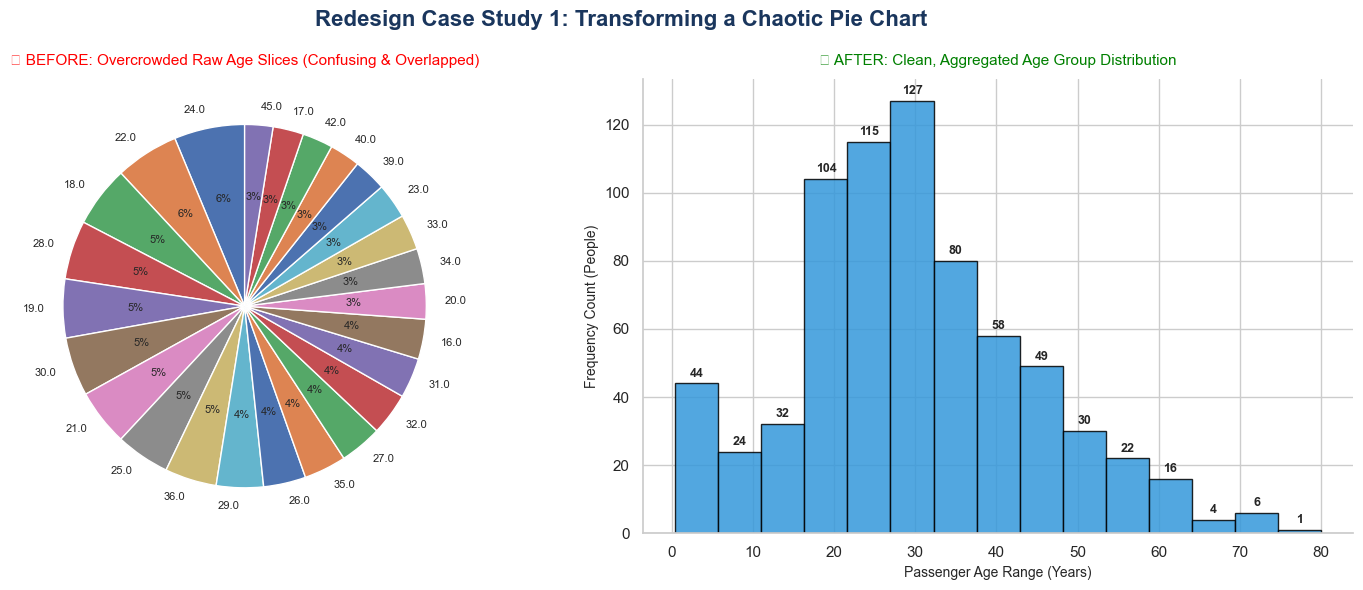

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a side-by-side comparison figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Redesign Case Study 1: Transforming a Chaotic Pie Chart', fontsize=16, fontweight='bold', color='#1a365d')

# --- LEFT SIDE: The Bad Visual (What NOT to do) ---
# We force raw age counts into a pie chart to simulate a poorly designed chart
age_counts = titanic['age'].value_counts().head(25) # Top 25 values
axes[0].pie(age_counts.values, labels=age_counts.index, autopct='%1.0f%%', startangle=90, textprops={'fontsize': 8})
axes[0].set_title('❌ BEFORE: Overcrowded Raw Age Slices (Confusing & Overlapped)', fontsize=11, color='red', pad=10)

# --- RIGHT SIDE: The Redesign Solution (Fixed Layout) ---
# We transform it into our polished binned frequency histogram with despining
counts, bins, patches = axes[1].hist(titanic['age'], bins=15, edgecolor='black', color='#3498db', alpha=0.85)
axes[1].set_title('✅ AFTER: Clean, Aggregated Age Group Distribution', fontsize=11, color='green', pad=10)
axes[1].set_xlabel('Passenger Age Range (Years)', fontsize=10)
axes[1].set_ylabel('Frequency Count (People)', fontsize=10)
sns.despine(ax=axes[1])

# Add numbers on top of the fixed bars
for i in range(len(patches)):
    if counts[i] > 0:
        axes[1].text(patches[i].get_x() + patches[i].get_width()/2, counts[i] + 2, f'{int(counts[i])}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


### ❌ Critique 2: Truncated Y-Axis Survival Rates Bar Chart
* **Major Flaw 1 (Visual Dishonesty):** Truncating or heavily altering a bar chart's vertical Y-axis axis baseline zoom level visually exaggerates tiny numerical discrepancies, giving a false impression of a massive scale shift.
* **Major Flaw 2 (Missing Labels & Orientation):** Leaving axis metrics unlabelled or omitting proper structural labels leaves the viewer guessing what units of measurement are being illustrated.
* **Major Flaw 3 (Poor Contrast):** Utilizing zero color boundaries or using identical muted tones makes it hard for individuals with visual impairments to tell the categories apart.

**Proposed Redesign Fix:** Use a clean, non-truncated categorical count plot starting exactly at zero, layered with rich contrasting hues, proper titles, and explicit text data tags.


C:\Users\User\AppData\Local\Temp\ipykernel_10016\2335260962.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_10016\2335260962.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()


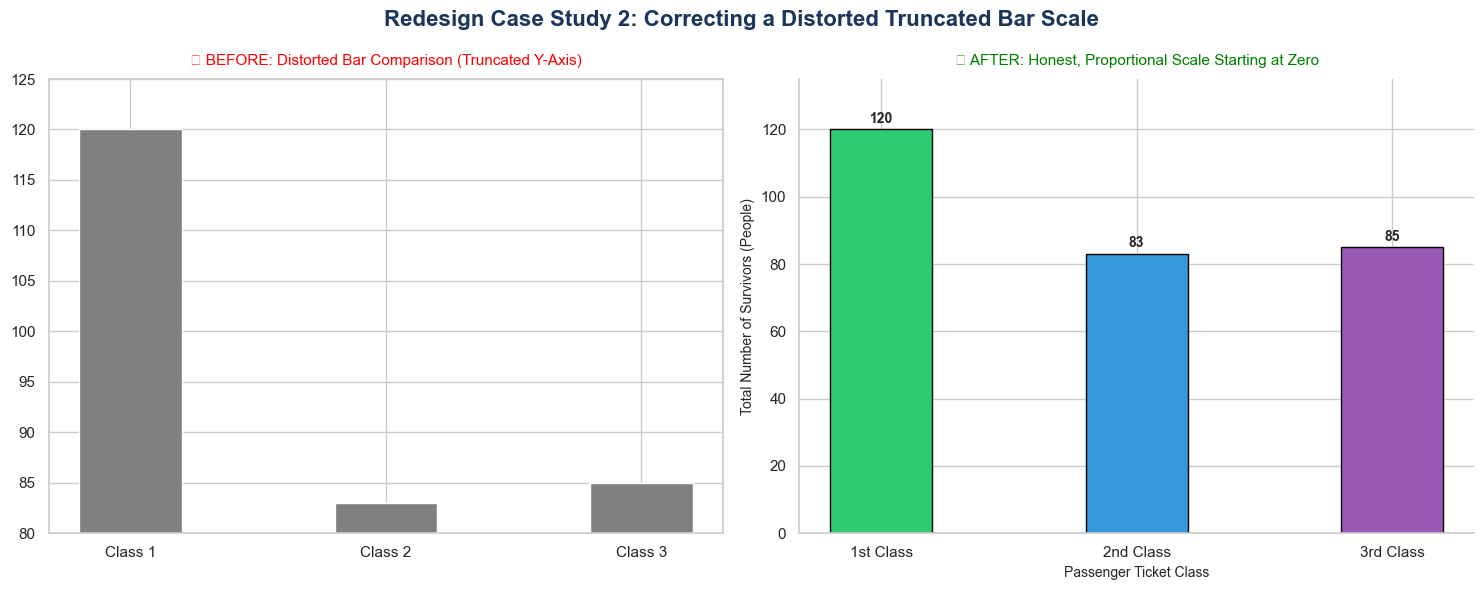

In [29]:
# Create a side-by-side comparison figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Redesign Case Study 2: Correcting a Distorted Truncated Bar Scale', fontsize=16, fontweight='bold', color='#1a365d')

# --- LEFT SIDE: The Bad Visual (Truncated Axis Example) ---
# We artificially truncate the axis baseline to exaggerate differences badly
class_survival_data = titanic.groupby('pclass')['survived'].sum()
axes[0].bar(['Class 1', 'Class 2', 'Class 3'], class_survival_data.values, color='gray', width=0.4)
axes[0].set_title('❌ BEFORE: Distorted Bar Comparison (Truncated Y-Axis)', fontsize=11, color='red', pad=10)
axes[0].set_ylim(80, 125) # Distorts the view by chopping off the bottom of the bars!

# --- RIGHT SIDE: The Redesign Solution (Corrected Baseline) ---
# We reset the axis to start honestly at zero and add descriptive formatting
bars = axes[1].bar(['1st Class', '2nd Class', '3rd Class'], class_survival_data.values, color=['#2ecc71', '#3498db', '#9b59b6'], width=0.4, edgecolor='black')
axes[1].set_title('✅ AFTER: Honest, Proportional Scale Starting at Zero', fontsize=11, color='green', pad=10)
axes[1].set_xlabel('Passenger Ticket Class', fontsize=10)
axes[1].set_ylabel('Total Number of Survivors (People)', fontsize=10)
axes[1].set_ylim(0, max(class_survival_data.values) + 15) # Safe padding starting at 0
sns.despine(ax=axes[1])

# Add text values to the redesign
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
